# 03 Fractional OU Estimation

Fit the fractional OU model to all retained formation spreads. The next module applies anti-persistence and numerical-stability eligibility rules.

Run cells from top to bottom, or choose **Run All** for this notebook only. Each module saves its outputs for the next notebook. Restart the kernel after pulling code changes.


## 1. Imports and saved run


In [1]:
%matplotlib inline
from pathlib import Path
import sys
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'research_config.py').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Open Jupyter inside the Pairs_trading repository.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src.project_io import OUTPUT_DIR, initialize, load_config, load_frame, save_frame, save_json

cfg = load_config()


## 2. Load selected formation spreads

No out-of-sample prices enter estimation.


In [2]:
selected = load_frame('cointegrated_pairs')
formation_spreads = load_frame('formation_spreads')
spreads = {(r.dependent, r.independent): formation_spreads[r.pair] for r in selected.itertuples()}
display(selected[['pair', 'alpha', 'beta']].head())


,pair,alpha,beta
0,A-MTD,-1.907639,0.943142
1,AAPL-MPWR,-0.863083,0.975501
2,ABT-STE,-0.415048,0.961633
3,ABT-ZTS,0.338157,0.841182
4,ACN-HD,-0.404943,1.065076


## 3. Estimate parameters

The continuous-time stationary-variance estimate and daily Euler simulator remain model approximations. Fit errors and boundary H estimates are recorded.


In [3]:
from src.fractional_OU import fit_cointegrated_pairs_fractional_ou
fou, fit_audit = fit_cointegrated_pairs_fractional_ou(spreads, selected, return_audit=True)
save_frame('fou_fit_audit', fit_audit)
if fou.empty:
    raise ValueError('No valid fOU fits. Inspect fou_fit_audit.')
save_frame('fractional_ou_parameters', fou)
display(fou.head(10))
display(fit_audit.head(10))


,pair,dependent,independent,mu,kappa,sigma,hurst,variance,drift_half_life,n_obs
0,A-MTD,A,MTD,7.955231e-15,0.019417,0.012516,0.482774,0.003472,35.697433,1759
1,AAPL-MPWR,AAPL,MPWR,8.602051e-15,0.008272,0.019680,0.411488,0.009393,83.792752,1759
2,ABT-STE,ABT,STE,-6.498497e-15,0.021089,0.014017,0.487555,0.004188,32.868084,1759
3,ABT-ZTS,ABT,ZTS,-7.119061e-15,0.021357,0.013038,0.492385,0.003729,32.455613,1759
4,ACN-HD,ACN,HD,2.183939e-14,0.040044,0.014830,0.536042,0.003576,17.309656,1759
5,ADBE-DPZ,ADBE,DPZ,3.587857e-14,0.011598,0.027156,0.436862,0.017258,59.762358,1759
6,ADI-CDNS,ADI,CDNS,-2.183737e-14,0.002265,0.014955,0.337950,0.006203,306.043089,1759
7,ADI-KEYS,ADI,KEYS,-4.623173e-15,0.002845,0.015250,0.346370,0.006123,243.671923,1759
8,ADI-TXN,ADI,TXN,3.901623e-14,0.004046,0.010806,0.357028,0.002721,171.328988,1759
9,ADP-MSI,ADP,MSI,3.167954e-14,0.013318,0.013528,0.428427,0.003509,52.047323,1759


,pair,status,error,hurst_at_clip_boundary,daily_euler_stable
0,A-MTD,fitted,,False,True
1,AAPL-MPWR,fitted,,False,True
2,ABT-STE,fitted,,False,True
3,ABT-ZTS,fitted,,False,True
4,ACN-HD,fitted,,False,True
5,ADBE-DPZ,fitted,,False,True
6,ADI-CDNS,fitted,,False,True
7,ADI-KEYS,fitted,,False,True
8,ADI-TXN,fitted,,False,True
9,ADP-MSI,fitted,,False,True


## 4. Hurst summary

The summary refers to exactly the fitted population saved above.


count    98.000000
mean      0.468032
std       0.062623
min       0.324004
25%       0.425398
50%       0.472517
75%       0.510871
max       0.595125
Name: hurst, dtype: float64

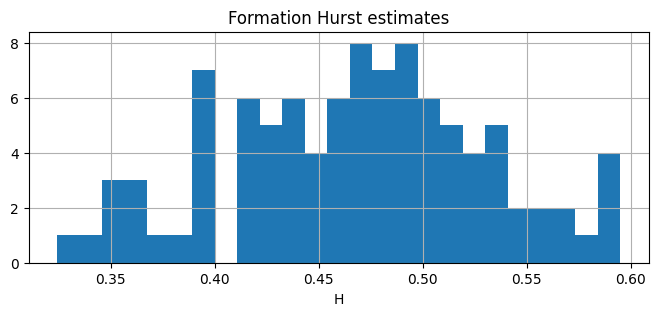

In [4]:
hurst_summary = fou.hurst.describe()
save_frame('hurst_summary', hurst_summary.to_frame('hurst'))
display(hurst_summary)
fou.hurst.hist(bins=25, figsize=(8, 3))
plt.title('Formation Hurst estimates')
plt.xlabel('H')
plt.show()


## Save module completion

Wait for this confirmation before moving to the next notebook.


In [5]:
print(f'Completed. Files saved in {OUTPUT_DIR}')


Completed. Files saved in /home/runner/work/Pairs_trading/Pairs_trading/data/processed/current
